# Classification: Cane Corso Growth Status

This notebook applies the second course topic: **Classification**.

The goal is to use the processed real public dog growth sample and build classification models step by step.

The classification task will not provide veterinary diagnosis. It will only classify records into educational growth-status categories for machine learning practice.


## Course Topic Coverage

This notebook will follow the Classification lecture step by step:

1. Classification problem statement and motivation
2. Logistic Regression
3. Binary classification
4. Data preparation: encoding, scaling, train/test split, class balance
5. Evaluation: confusion matrix, accuracy, precision, recall, F1
6. ROC curve and AUC
7. Decision Trees
8. Ensemble models
9. Support Vector Machines
10. Final model comparison and interpretation


## Problem Statement

In the previous notebook, the project used regression to predict a numerical value: dog weight.

In this notebook, the task changes from predicting a number to predicting a class.

The planned classification target is `growth_status`:

- `normal_growth`
- `needs_attention`

This target will be created from body condition score information in the processed real dataset.


## Dataset

This notebook uses the classification-focused processed real public dog growth sample:

`data/processed/dog_growth_classification_sample.csv`

This file was created from the real public dog growth dataset and includes usable body condition score information.

The original raw dataset is not committed to GitHub. Only the smaller processed classification sample is used in this notebook.


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [42]:
data_path = '../data/processed/dog_growth_classification_sample.csv'
df = pd.read_csv(data_path)
df.head()


,breed_id,pet_id,gender,visit_age_years,visit_age_months,weight_kg,bcs_recorded,bcs_predicted,bcs_source,growth_status,growth_status_binary,preventive_care_visit,healthy_pet_diagnosis,average_adult_breed_weight_kg,source_type
0,11,952307,FS,2.771,33.25,33.384,NaN,Normal,Normal,normal_growth,0,Y,N,35.91,real_public_classification_sample
1,11,952307,FS,2.779,33.35,33.384,NaN,Normal,Normal,normal_growth,0,N,N,35.91,real_public_classification_sample
2,11,952458,FS,2.503,30.04,33.793,NaN,Normal,Normal,normal_growth,0,N,N,35.91,real_public_classification_sample
3,11,952555,FS,2.966,35.59,37.013,NaN,Normal,Normal,normal_growth,0,Y,N,35.91,real_public_classification_sample
4,11,952579,FS,2.026,24.31,30.663,NaN,Normal,Normal,normal_growth,0,N,N,35.91,real_public_classification_sample


## Initial Dataset Check

Before creating the classification target, I first inspect the dataset shape, columns, and basic values.


In [43]:
df.shape


(10000, 15)

In [44]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   breed_id                       10000 non-null  int64  
 1   pet_id                         10000 non-null  int64  
 2   gender                         10000 non-null  str    
 3   visit_age_years                10000 non-null  float64
 4   visit_age_months               10000 non-null  float64
 5   weight_kg                      10000 non-null  float64
 6   bcs_recorded                   6350 non-null   str    
 7   bcs_predicted                  3650 non-null   str    
 8   bcs_source                     10000 non-null  str    
 9   growth_status                  10000 non-null  str    
 10  growth_status_binary           10000 non-null  int64  
 11  preventive_care_visit          10000 non-null  str    
 12  healthy_pet_diagnosis          10000 non-null  str    
 13

In [45]:
df[['bcs_recorded', 'bcs_predicted', 'bcs_source', 'growth_status', 'growth_status_binary', 'source_type']].head(10)


,bcs_recorded,bcs_predicted,bcs_source,growth_status,growth_status_binary,source_type
0,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
1,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
2,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
3,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
4,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
5,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
6,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
7,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
8,NaN,Normal,Normal,normal_growth,0,real_public_classification_sample
9,Normal,NaN,Normal,normal_growth,0,real_public_classification_sample


## Create Classification Target

The classification-focused processed sample already contains the target columns:

- `growth_status`
- `growth_status_binary`

The target is based on body condition score information:

- `Normal` becomes `normal_growth`
- `Thin` or `Heavy` becomes `needs_attention`

This is not a veterinary diagnosis. It is only an educational classification label used to practice machine learning methods.


In [46]:
classification_df = df.dropna(subset=["growth_status", "growth_status_binary"]).copy()

classification_df["growth_status_binary"] = classification_df["growth_status_binary"].astype(int)

classification_df[[
    "bcs_recorded",
    "bcs_predicted",
    "bcs_source",
    "growth_status",
    "growth_status_binary"
]].head(10)


,bcs_recorded,bcs_predicted,bcs_source,growth_status,growth_status_binary
0,NaN,Normal,Normal,normal_growth,0
1,NaN,Normal,Normal,normal_growth,0
2,NaN,Normal,Normal,normal_growth,0
3,NaN,Normal,Normal,normal_growth,0
4,NaN,Normal,Normal,normal_growth,0
5,NaN,Normal,Normal,normal_growth,0
6,NaN,Normal,Normal,normal_growth,0
7,NaN,Normal,Normal,normal_growth,0
8,NaN,Normal,Normal,normal_growth,0
9,Normal,NaN,Normal,normal_growth,0


In [47]:
classification_df["growth_status"].value_counts()

growth_status
normal_growth      5000
needs_attention    5000
Name: count, dtype: int64

In [48]:
classification_df["growth_status"].value_counts(normalize=True).round(3)

growth_status
normal_growth      0.5
needs_attention    0.5
Name: proportion, dtype: float64

In [49]:
classification_df[["growth_status", "growth_status_binary"]].drop_duplicates().sort_values("growth_status_binary")


,growth_status,growth_status_binary
0,normal_growth,0
5000,needs_attention,1


### Target Interpretation

The `growth_status_binary` column is the numeric target for binary classification.

- `0` means `normal_growth`
- `1` means `needs_attention`

This target allows the project to apply Logistic Regression and other classification models from the course.

## Logistic Regression Classifier

Logistic Regression is the first classification model in this notebook.

The model will predict whether a record belongs to:

- `normal_growth`
- `needs_attention`

The target column is `growth_status_binary`.

The model will use several input features from the processed real dog growth sample.

In [51]:
classification_features = pd.get_dummies(
    classification_df[
        [
            "visit_age_months",
            "weight_kg",
            "average_adult_breed_weight_kg",
            "gender",
            "preventive_care_visit",
            "healthy_pet_diagnosis"
        ]
    ],
    drop_first=True
)

classification_target = classification_df["growth_status_binary"]

classification_features.head()

,visit_age_months,weight_kg,average_adult_breed_weight_kg,gender_FS,gender_M,gender_MN,preventive_care_visit_Y,healthy_pet_diagnosis_Y
0,33.25,33.384,35.91,True,False,False,True,False
1,33.35,33.384,35.91,True,False,False,False,False
2,30.04,33.793,35.91,True,False,False,False,False
3,35.59,37.013,35.91,True,False,False,True,False
4,24.31,30.663,35.91,True,False,False,False,False


In [52]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    classification_features,
    classification_target,
    test_size=0.25,
    random_state=42,
    stratify=classification_target
)

print("Training rows:", X_train_cls.shape[0])
print("Test rows:", X_test_cls.shape[0])
print("Training class balance:")
print(y_train_cls.value_counts(normalize=True).round(3))
print("Test class balance:")
print(y_test_cls.value_counts(normalize=True).round(3))

Training rows: 7500
Test rows: 2500
Training class balance:
growth_status_binary
1    0.5
0    0.5
Name: proportion, dtype: float64
Test class balance:
growth_status_binary
0    0.5
1    0.5
Name: proportion, dtype: float64


In [53]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logistic_model.fit(X_train_cls, y_train_cls)

logistic_predictions = logistic_model.predict(X_test_cls)
logistic_probabilities = logistic_model.predict_proba(X_test_cls)[:, 1]

In [54]:
logistic_results = pd.DataFrame({
    "actual_class": y_test_cls.values,
    "predicted_class": logistic_predictions,
    "needs_attention_probability": logistic_probabilities.round(3)
})

logistic_results.head(10)

,actual_class,predicted_class,needs_attention_probability
0,0,0,0.000
1,1,1,0.830
2,0,0,0.001
3,1,1,0.765
4,1,1,0.727
5,0,0,0.319
6,0,1,0.593
7,0,1,0.588
8,0,0,0.463
9,0,1,0.775


### Logistic Regression Notes

The Logistic Regression model predicts a binary class:

- `0` = normal growth
- `1` = needs attention

The probability column shows how confident the model is that a record belongs to the `needs_attention` class.

The next step will evaluate this classifier using confusion matrix, accuracy, precision, recall, and F1-score.

## Classification Evaluation

After training the Logistic Regression classifier, I evaluate the model using standard classification metrics.

The evaluation includes:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-score

These metrics help explain how well the classifier predicts `normal_growth` and `needs_attention`.

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

In [57]:
logistic_confusion_matrix = confusion_matrix(
    y_test_cls,
    logistic_predictions
)

logistic_confusion_matrix

array([[ 903,  347],
       [ 124, 1126]])

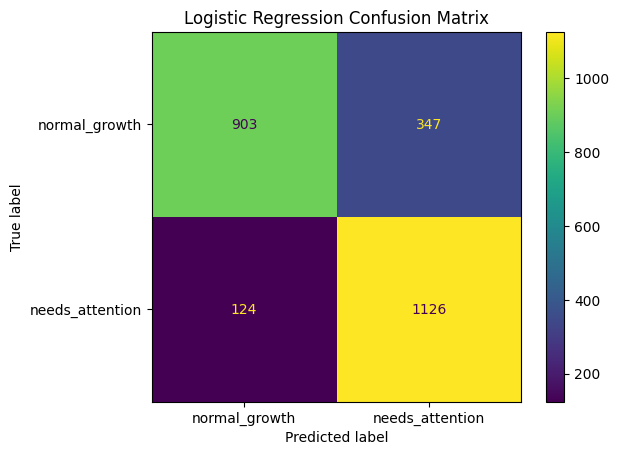

In [58]:
ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=["normal_growth", "needs_attention"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [59]:
logistic_accuracy = accuracy_score(y_test_cls, logistic_predictions)
logistic_precision = precision_score(y_test_cls, logistic_predictions, zero_division=0)
logistic_recall = recall_score(y_test_cls, logistic_predictions, zero_division=0)
logistic_f1 = f1_score(y_test_cls, logistic_predictions, zero_division=0)

logistic_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1
    ]
})

logistic_metrics

,Metric,Value
0,Accuracy,0.811600
1,Precision,0.764426
2,Recall,0.900800
3,F1-score,0.827029


In [60]:
print(
    classification_report(
        y_test_cls,
        logistic_predictions,
        target_names=["normal_growth", "needs_attention"],
        zero_division=0
    )
)

                 precision    recall  f1-score   support

  normal_growth       0.88      0.72      0.79      1250
needs_attention       0.76      0.90      0.83      1250

       accuracy                           0.81      2500
      macro avg       0.82      0.81      0.81      2500
   weighted avg       0.82      0.81      0.81      2500



### Evaluation Interpretation

The confusion matrix shows how many records were classified correctly and incorrectly.

Accuracy shows the overall percentage of correct predictions.

Precision shows how many records predicted as `needs_attention` were actually `needs_attention`.

Recall shows how many actual `needs_attention` records were found by the model.

F1-score combines precision and recall into one metric.

For this project, recall is especially important because missing a `needs_attention` case may be more problematic than marking a normal case for additional review. This is still only an educational classification experiment and not a veterinary diagnosis.

## ROC Curve and AUC

The ROC curve is used to evaluate a binary classifier at different probability thresholds.

It compares:

- True Positive Rate
- False Positive Rate

The AUC score summarizes the ROC curve in a single number. A value closer to 1 means better classification performance.

In [63]:
logistic_fpr, logistic_tpr, logistic_thresholds = roc_curve(
    y_test_cls,
    logistic_probabilities
)

logistic_auc = roc_auc_score(
    y_test_cls,
    logistic_probabilities
)

logistic_auc

0.88860512

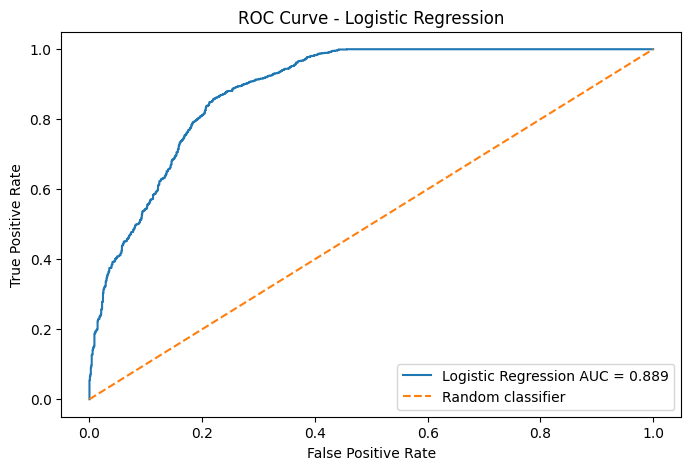

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(logistic_fpr, logistic_tpr, label=f"Logistic Regression AUC = {logistic_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### ROC / AUC Interpretation

The ROC curve shows how the classifier behaves when the decision threshold changes.

The dashed diagonal line represents a random classifier.

A curve closer to the upper-left corner means better performance.

The AUC score summarizes this behavior. In this project, it helps evaluate how well Logistic Regression separates `normal_growth` from `needs_attention`.

## Decision Tree Classifier

Decision Trees are classification models that split the data step by step.

They are easier to interpret than many other models because the final prediction is made by following a path from the root node to a leaf node.

In this experiment, I train a Decision Tree classifier and compare its results with Logistic Regression.

In [65]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight="balanced"
)

decision_tree_model.fit(X_train_cls, y_train_cls)

tree_predictions = decision_tree_model.predict(X_test_cls)
tree_probabilities = decision_tree_model.predict_proba(X_test_cls)[:, 1]

In [66]:
tree_accuracy = accuracy_score(y_test_cls, tree_predictions)
tree_precision = precision_score(y_test_cls, tree_predictions, zero_division=0)
tree_recall = recall_score(y_test_cls, tree_predictions, zero_division=0)
tree_f1 = f1_score(y_test_cls, tree_predictions, zero_division=0)
tree_auc = roc_auc_score(y_test_cls, tree_probabilities)

tree_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_auc
    ]
})

tree_metrics

,Metric,Decision Tree
0,Accuracy,0.822800
1,Precision,0.777701
2,Recall,0.904000
3,F1-score,0.836108
4,AUC,0.888788


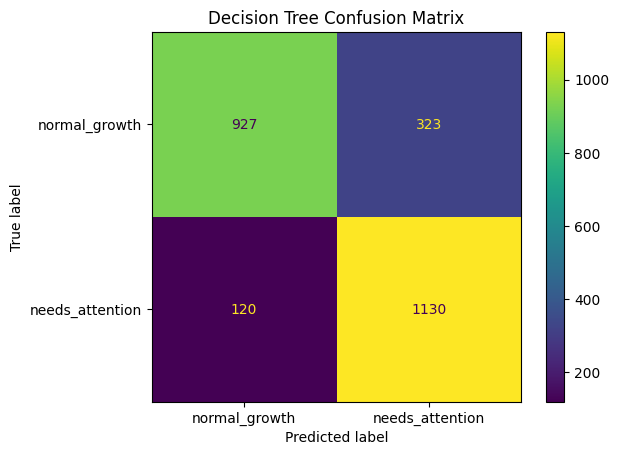

In [67]:
tree_confusion_matrix = confusion_matrix(
    y_test_cls,
    tree_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=tree_confusion_matrix,
    display_labels=["normal_growth", "needs_attention"]
).plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [68]:
tree_feature_importance = pd.DataFrame({
    "Feature": classification_features.columns,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

tree_feature_importance

,Feature,Importance
2,average_adult_breed_weight_kg,0.698745
0,visit_age_months,0.192064
1,weight_kg,0.071994
7,healthy_pet_diagnosis_Y,0.027014
5,gender_MN,0.010183
3,gender_FS,0.000000
4,gender_M,0.000000
6,preventive_care_visit_Y,0.000000


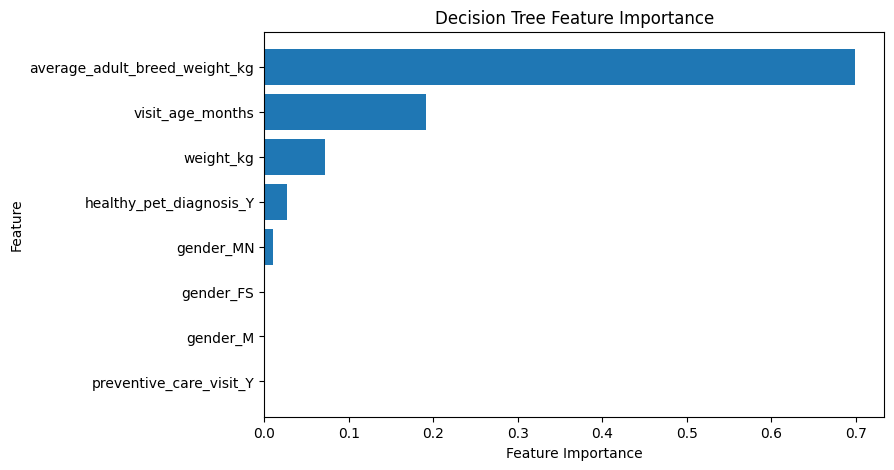

In [69]:
plt.figure(figsize=(8, 5))
plt.barh(
    tree_feature_importance["Feature"],
    tree_feature_importance["Importance"]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### Decision Tree Interpretation

The Decision Tree classifier provides a more interpretable model than Logistic Regression.

The feature importance table shows which input features were most useful for making classification decisions.

The `max_depth` parameter is used to limit the tree and reduce overfitting. A very deep tree may memorize the training data instead of learning a useful pattern.

This model is still used only for educational classification practice and does not provide veterinary diagnosis.

## Ensemble Models: Random Forest and AdaBoost

Ensemble models combine multiple weaker models into a stronger model.

In this section, I test two ensemble classifiers:

- Random Forest Classifier
- AdaBoost Classifier

Random Forest combines multiple decision trees and usually reduces overfitting compared to a single tree.

AdaBoost combines weak learners and focuses more on samples that were misclassified by previous learners.

In [70]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train_cls, y_train_cls)

forest_predictions = random_forest_model.predict(X_test_cls)
forest_probabilities = random_forest_model.predict_proba(X_test_cls)[:, 1]

In [71]:
forest_accuracy = accuracy_score(y_test_cls, forest_predictions)
forest_precision = precision_score(y_test_cls, forest_predictions, zero_division=0)
forest_recall = recall_score(y_test_cls, forest_predictions, zero_division=0)
forest_f1 = f1_score(y_test_cls, forest_predictions, zero_division=0)
forest_auc = roc_auc_score(y_test_cls, forest_probabilities)

forest_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Random Forest": [
        forest_accuracy,
        forest_precision,
        forest_recall,
        forest_f1,
        forest_auc
    ]
})

forest_metrics

,Metric,Random Forest
0,Accuracy,0.832400
1,Precision,0.786749
2,Recall,0.912000
3,F1-score,0.844757
4,AUC,0.911906


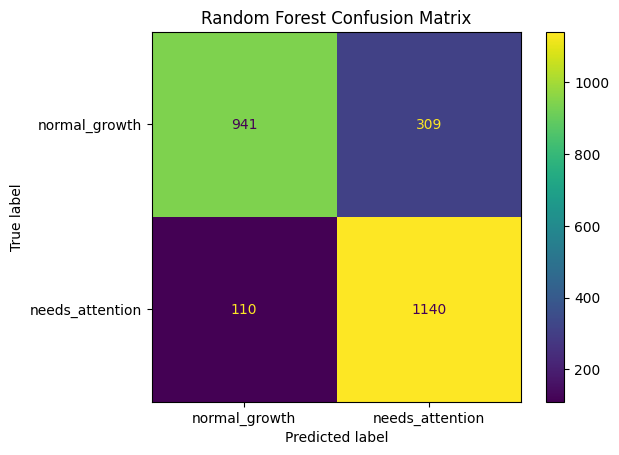

In [72]:
forest_confusion_matrix = confusion_matrix(
    y_test_cls,
    forest_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=forest_confusion_matrix,
    display_labels=["normal_growth", "needs_attention"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [73]:
forest_feature_importance = pd.DataFrame({
    "Feature": classification_features.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

forest_feature_importance

,Feature,Importance
1,weight_kg,0.410096
2,average_adult_breed_weight_kg,0.400346
0,visit_age_months,0.125623
7,healthy_pet_diagnosis_Y,0.045458
4,gender_M,0.006468
3,gender_FS,0.004983
5,gender_MN,0.003695
6,preventive_care_visit_Y,0.003331


In [74]:
ada_base_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

adaboost_model = AdaBoostClassifier(
    estimator=ada_base_tree,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

adaboost_model.fit(X_train_cls, y_train_cls)

adaboost_predictions = adaboost_model.predict(X_test_cls)
adaboost_probabilities = adaboost_model.predict_proba(X_test_cls)[:, 1]

In [75]:
adaboost_accuracy = accuracy_score(y_test_cls, adaboost_predictions)
adaboost_precision = precision_score(y_test_cls, adaboost_predictions, zero_division=0)
adaboost_recall = recall_score(y_test_cls, adaboost_predictions, zero_division=0)
adaboost_f1 = f1_score(y_test_cls, adaboost_predictions, zero_division=0)
adaboost_auc = roc_auc_score(y_test_cls, adaboost_probabilities)

adaboost_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "AdaBoost": [
        adaboost_accuracy,
        adaboost_precision,
        adaboost_recall,
        adaboost_f1,
        adaboost_auc
    ]
})

adaboost_metrics

,Metric,AdaBoost
0,Accuracy,0.770800
1,Precision,0.685683
2,Recall,1.000000
3,F1-score,0.813537
4,AUC,0.874921


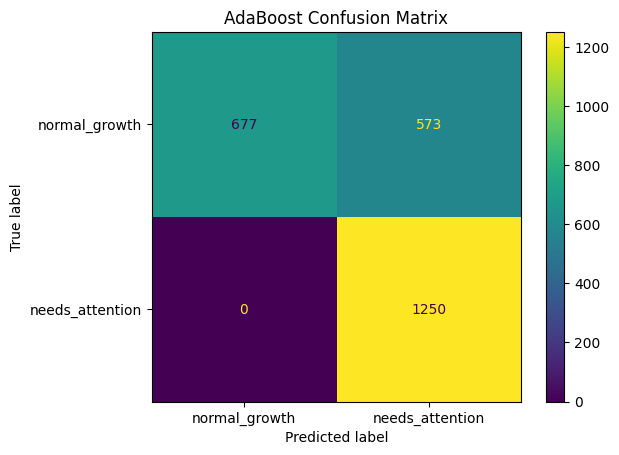

In [76]:
adaboost_confusion_matrix = confusion_matrix(
    y_test_cls,
    adaboost_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=adaboost_confusion_matrix,
    display_labels=["normal_growth", "needs_attention"]
).plot()

plt.title("AdaBoost Confusion Matrix")
plt.show()

### Ensemble Model Interpretation

Random Forest uses many decision trees and combines their predictions. This can make the model more stable than a single decision tree.

AdaBoost uses weak learners and gives more attention to samples that were harder to classify.

Both models are useful for comparison because the lecture explains that no single classifier is always best. Different algorithms should be compared on the same problem.

In this project, the ensemble models are used only for educational classification practice and not for veterinary diagnosis.

## Support Vector Machine Classifier

Support Vector Machines are classification models that try to find a decision boundary between classes.

The idea is to separate the classes with the largest possible margin.

In this experiment, I use an SVM classifier with an RBF kernel. The RBF kernel can model non-linear relationships between the input features and the target class.

In [77]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train_cls, y_train_cls)

svm_predictions = svm_model.predict(X_test_cls)
svm_scores = svm_model.decision_function(X_test_cls)

In [78]:
svm_accuracy = accuracy_score(y_test_cls, svm_predictions)
svm_precision = precision_score(y_test_cls, svm_predictions, zero_division=0)
svm_recall = recall_score(y_test_cls, svm_predictions, zero_division=0)
svm_f1 = f1_score(y_test_cls, svm_predictions, zero_division=0)
svm_auc = roc_auc_score(y_test_cls, svm_scores)

svm_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Support Vector Machine": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1,
        svm_auc
    ]
})

svm_metrics

,Metric,Support Vector Machine
0,Accuracy,0.831200
1,Precision,0.788301
2,Recall,0.905600
3,F1-score,0.842889
4,AUC,0.899020


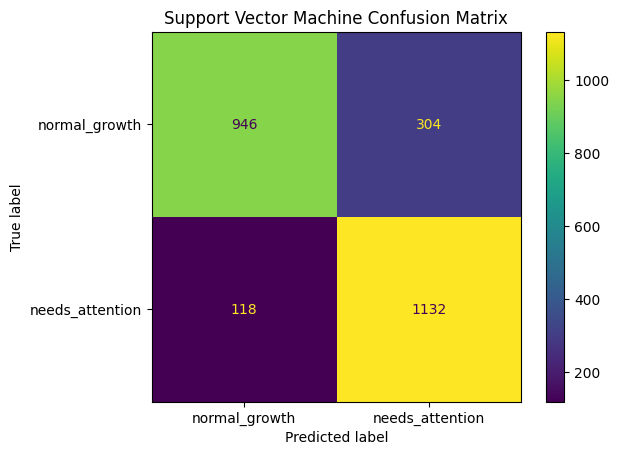

In [79]:
svm_confusion_matrix = confusion_matrix(
    y_test_cls,
    svm_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=svm_confusion_matrix,
    display_labels=["normal_growth", "needs_attention"]
).plot()

plt.title("Support Vector Machine Confusion Matrix")
plt.show()

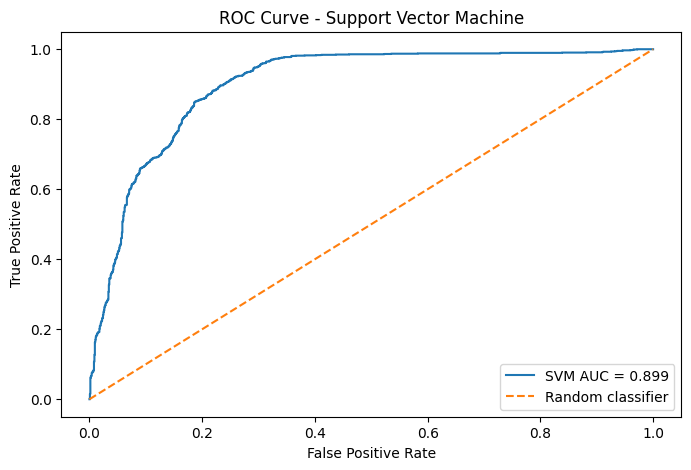

In [80]:
svm_fpr, svm_tpr, svm_thresholds = roc_curve(
    y_test_cls,
    svm_scores
)

plt.figure(figsize=(8, 5))
plt.plot(svm_fpr, svm_tpr, label=f"SVM AUC = {svm_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Support Vector Machine")
plt.legend()
plt.show()

### SVM Interpretation

The Support Vector Machine classifier uses a margin-based decision boundary.

The RBF kernel allows the model to capture non-linear relationships in the data.

The `C` parameter controls the penalty for misclassification. A smaller value gives stronger regularization, while a larger value allows the model to follow the training data more closely.

In this project, the SVM model is used as another classifier for comparison. It does not provide veterinary diagnosis.

## Final Classification Model Comparison

In this section, I compare all classification models tested in this notebook.

The models are compared using:

- Accuracy
- Precision
- Recall
- F1-score
- AUC

The goal is to understand how different classifiers behave on the same classification problem.

In [81]:
classification_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Support Vector Machine"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy,
        adaboost_accuracy,
        svm_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision,
        adaboost_precision,
        svm_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall,
        adaboost_recall,
        svm_recall
    ],
    "F1-score": [
        logistic_f1,
        tree_f1,
        forest_f1,
        adaboost_f1,
        svm_f1
    ],
    "AUC": [
        logistic_auc,
        tree_auc,
        forest_auc,
        adaboost_auc,
        svm_auc
    ]
})

classification_model_comparison

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.8116,0.764426,0.9008,0.827029,0.888605
1,Decision Tree,0.8228,0.777701,0.9040,0.836108,0.888788
2,Random Forest,0.8324,0.786749,0.9120,0.844757,0.911906
3,AdaBoost,0.7708,0.685683,1.0000,0.813537,0.874921
4,Support Vector Machine,0.8312,0.788301,0.9056,0.842889,0.899020


In [82]:
classification_model_comparison.sort_values(
    by="F1-score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score,AUC
2,Random Forest,0.8324,0.786749,0.9120,0.844757,0.911906
4,Support Vector Machine,0.8312,0.788301,0.9056,0.842889,0.899020
1,Decision Tree,0.8228,0.777701,0.9040,0.836108,0.888788
0,Logistic Regression,0.8116,0.764426,0.9008,0.827029,0.888605
3,AdaBoost,0.7708,0.685683,1.0000,0.813537,0.874921


In [83]:
classification_model_comparison.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score,AUC
3,AdaBoost,0.7708,0.685683,1.0000,0.813537,0.874921
2,Random Forest,0.8324,0.786749,0.9120,0.844757,0.911906
4,Support Vector Machine,0.8312,0.788301,0.9056,0.842889,0.899020
1,Decision Tree,0.8228,0.777701,0.9040,0.836108,0.888788
0,Logistic Regression,0.8116,0.764426,0.9008,0.827029,0.888605


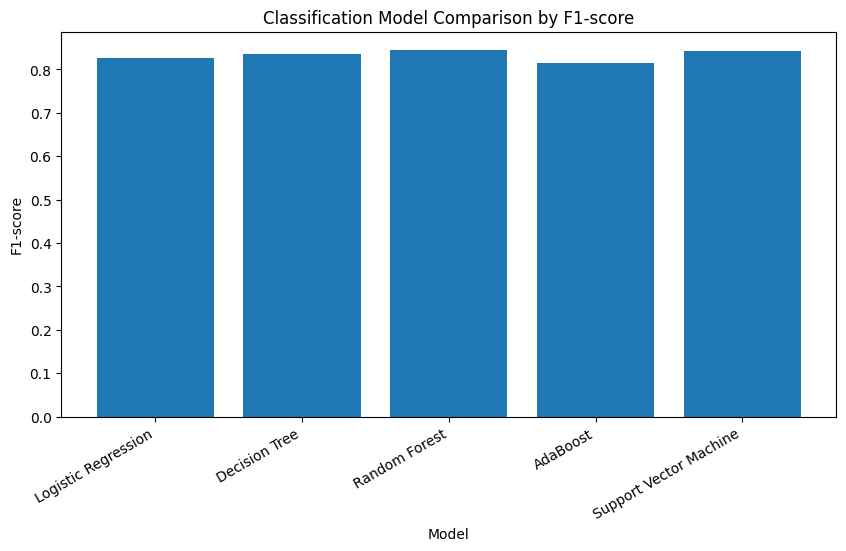

In [84]:
plt.figure(figsize=(10, 5))

plt.bar(
    classification_model_comparison["Model"],
    classification_model_comparison["F1-score"]
)

plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("Classification Model Comparison by F1-score")
plt.xticks(rotation=30, ha="right")
plt.show()

### Final Classification Interpretation

The final comparison table shows how the tested classification models perform on the same dataset and target.

Logistic Regression is useful as a simple and interpretable baseline model.

Decision Tree is easier to interpret because it makes decisions through a sequence of feature splits.

Random Forest and AdaBoost are ensemble models. They combine multiple weak learners and can improve performance compared to a single tree.

Support Vector Machine uses a margin-based decision boundary and can model non-linear relationships through the RBF kernel.

For this project, recall is especially important because the `needs_attention` class represents records that should not be missed. However, this is still an educational classification task and does not provide veterinary diagnosis.

The best model should not be selected only by one metric. Accuracy, precision, recall, F1-score, AUC, interpretability, and project limitations should all be considered together.